# E-Commerce Customer Funnel & Conversion Analysis

## Business Objective

This project analyzes e-commerce customer session data to understand
customer conversion, marketing campaign performance, product/category
performance, and product returns.

The analysis aims to identify funnel drop-offs, high-performing
customer and product segments, and opportunities to improve conversion,
revenue, and customer experience.

## Key Business Questions

1. What percentage of customer sessions result in an order?
2. Where are customers dropping out of the purchasing funnel?
3. Which marketing campaigns generate the best conversion and revenue?
4. Which product categories and products perform best?
5. Which customer segments contribute the most value?
6. What are the major reasons for product returns?
7. Which areas present opportunities for business improvement?

## Tools

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SQL
- Power BI

LOAD THE DATASET

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
df = pd.read_csv("/Users/macbookair/Desktop/Data_Analyst/Funnel-Analysis/Data/Customer-Insights-Raw.csv")

In [3]:
df.head()

,SessionStart,CustomerID,FullName,Gender,Age,CreditScore,MonthlyIncome,Country,State,City,Category,Product,Cost,Price,Quantity,CampaignSchema,CartAdditionTime,OrderConfirmation,OrderConfirmationTime,PaymentMethod,SessionEnd,OrderReturn,ReturnReason
0,2019-01-01 02:42:00,1001,Brittany Franklin,Male,57,780,7591,China,Guangdong,Dongguan,electronics,table fan,30,50,4,Instagram-ads,2019-01-01 02:49:00,True,2019-01-01 03:02:00,Cash On Delivery,2019-01-01 02:53:00,False,NaN
1,2019-01-02 20:35:00,1002,Scott Stewart,Female,69,746,3912,China,Shandong,Yantai,fashion,dress,50,80,6,Google-ads,2019-01-02 20:50:00,True,2019-01-02 20:58:00,Debit Card,2019-01-02 20:54:00,False,NaN
2,2019-01-04 03:11:00,1003,Elizabeth Fowler,Female,21,772,7460,UK,England,Birmingham,toys,plush toy,12,20,2,Facebook-ads,2019-01-04 03:30:00,True,2019-01-04 03:40:00,Cash On Delivery,2019-01-04 03:35:00,False,NaN
3,2019-01-05 09:01:00,1004,Julian Wall,Female,67,631,4765,UK,England,Birmingham,toys,plush toy,12,20,2,Twitter-ads,2019-01-05 09:17:00,True,2019-01-05 09:26:00,Cash On Delivery,2019-01-05 09:20:00,False,NaN
4,2019-01-05 13:35:00,1005,James Simmons,Male,57,630,3268,China,Shandong,Yantai,fashion,shoes,60,100,6,Billboard-QR code,2019-01-05 13:40:00,True,2019-01-05 13:52:00,Debit Card,2019-01-05 13:42:00,False,NaN


In [4]:
df.shape

(2000, 23)

In [5]:
df.columns.tolist()

['SessionStart',
 'CustomerID',
 'FullName',
 'Gender',
 'Age',
 'CreditScore',
 'MonthlyIncome',
 'Country',
 'State',
 'City',
 'Category',
 'Product',
 'Cost',
 'Price',
 'Quantity',
 'CampaignSchema ',
 'CartAdditionTime',
 'OrderConfirmation',
 'OrderConfirmationTime',
 'PaymentMethod',
 'SessionEnd',
 'OrderReturn',
 'ReturnReason']

********** DATA INSPECTION **************

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   SessionStart           2000 non-null   str   
 1   CustomerID             2000 non-null   int64 
 2   FullName               2000 non-null   str   
 3   Gender                 2000 non-null   str   
 4   Age                    2000 non-null   int64 
 5   CreditScore            2000 non-null   int64 
 6   MonthlyIncome          2000 non-null   int64 
 7   Country                2000 non-null   str   
 8   State                  2000 non-null   str   
 9   City                   2000 non-null   str   
 10  Category               2000 non-null   str   
 11  Product                2000 non-null   str   
 12  Cost                   2000 non-null   int64 
 13  Price                  2000 non-null   int64 
 14  Quantity               2000 non-null   int64 
 15  CampaignSchema         2000 non-

In [7]:
df.describe()

,CustomerID,Age,CreditScore,MonthlyIncome,Cost,Price,Quantity
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1609.064000,44.487500,690.126500,5589.697000,135.816000,210.921500,3.527500
std,349.835233,16.350367,50.618066,1441.584931,261.935533,394.196811,1.697847
min,1001.000000,18.000000,600.000000,3001.000000,5.000000,8.000000,1.000000
25%,1311.000000,31.000000,646.000000,4403.500000,15.000000,25.000000,2.000000
50%,1610.000000,44.000000,691.000000,5656.500000,30.000000,50.000000,3.000000
75%,1915.250000,59.000000,732.000000,6856.250000,60.000000,100.000000,5.000000
max,2200.000000,72.000000,780.000000,7999.000000,1000.000000,1500.000000,6.000000


In [8]:
df.isnull().sum().sort_values(ascending=False)

ReturnReason             1764
OrderReturn               300
PaymentMethod             300
OrderConfirmationTime     300
Cost                        0
SessionEnd                  0
OrderConfirmation           0
CartAdditionTime            0
CampaignSchema              0
Quantity                    0
Price                       0
SessionStart                0
CustomerID                  0
Category                    0
City                        0
State                       0
Country                     0
MonthlyIncome               0
CreditScore                 0
Age                         0
Gender                      0
FullName                    0
Product                     0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.nunique().sort_values(ascending=False)

SessionStart             2000
CartAdditionTime         2000
SessionEnd               1999
OrderConfirmationTime    1700
CustomerID               1200
FullName                 1200
MonthlyIncome            1069
CreditScore               180
Age                        55
City                       52
Product                    20
State                      18
Price                      17
Cost                       15
Country                     9
Quantity                    6
CampaignSchema              6
Category                    5
ReturnReason                5
PaymentMethod               4
OrderConfirmation           2
Gender                      2
OrderReturn                 2
dtype: int64

In [11]:
df['OrderConfirmation'].value_counts(dropna=False)

OrderConfirmation
True     1700
False     300
Name: count, dtype: int64

In [12]:
pd.crosstab(
    df['OrderConfirmation'],
    df['OrderReturn'],
    dropna=False
)

OrderReturn,False,True,NaN
OrderConfirmation,,,
False,0,0,300
True,1464,236,0


In [13]:
df['OrderReturn'].value_counts(dropna=False)

OrderReturn
False    1464
NaN       300
True      236
Name: count, dtype: int64

In [14]:
df['OrderReturn'].unique()

array([False, True, nan], dtype=object)

************* DATA CLEANING ***************

In [15]:
df.columns = df.columns.str.strip()

In [16]:
df.columns.tolist()

['SessionStart',
 'CustomerID',
 'FullName',
 'Gender',
 'Age',
 'CreditScore',
 'MonthlyIncome',
 'Country',
 'State',
 'City',
 'Category',
 'Product',
 'Cost',
 'Price',
 'Quantity',
 'CampaignSchema',
 'CartAdditionTime',
 'OrderConfirmation',
 'OrderConfirmationTime',
 'PaymentMethod',
 'SessionEnd',
 'OrderReturn',
 'ReturnReason']

In [17]:
date_columns = [
    'SessionStart',
    'CartAdditionTime',
    'OrderConfirmationTime',
    'SessionEnd'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [18]:
df[date_columns].dtypes

SessionStart             datetime64[us]
CartAdditionTime         datetime64[us]
OrderConfirmationTime    datetime64[us]
SessionEnd               datetime64[us]
dtype: object

In [19]:
df[date_columns].isna().sum()

SessionStart               0
CartAdditionTime           0
OrderConfirmationTime    300
SessionEnd                 0
dtype: int64

In [20]:
numeric_columns = [
    'Age',
    'CreditScore',
    'MonthlyIncome',
    'Cost',
    'Price',
    'Quantity'
]

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2000.0,44.4875,16.350367,18.0,31.0,44.0,59.00,72.0
CreditScore,2000.0,690.1265,50.618066,600.0,646.0,691.0,732.00,780.0
MonthlyIncome,2000.0,5589.6970,1441.584931,3001.0,4403.5,5656.5,6856.25,7999.0
Cost,2000.0,135.8160,261.935533,5.0,15.0,30.0,60.00,1000.0
Price,2000.0,210.9215,394.196811,8.0,25.0,50.0,100.00,1500.0
Quantity,2000.0,3.5275,1.697847,1.0,2.0,3.0,5.00,6.0


In [21]:
df[numeric_columns].isna().sum()

Age              0
CreditScore      0
MonthlyIncome    0
Cost             0
Price            0
Quantity         0
dtype: int64

**************** FEATURE ENGINEERING ******************

In [22]:
df['IsConverted'] = df['OrderConfirmation']

df['IsConverted'].value_counts()

IsConverted
True     1700
False     300
Name: count, dtype: int64

In [23]:
df['IsReturned'] = df['OrderReturn'].fillna(False).astype(bool)
df['IsReturned'].value_counts()

IsReturned
False    1764
True      236
Name: count, dtype: int64

In [24]:
df['Revenue'] = df['Price'] * df['Quantity']

In [25]:
df['Profit'] = (df['Price'] - df['Cost']) * df['Quantity']

In [26]:
df['ProfitMargin'] = np.where(
    df['Revenue'] != 0,
    (df['Profit'] / df['Revenue']) * 100,
    0
)

In [27]:
df[['Cost', 'Price', 'Quantity', 'Revenue', 'Profit', 'ProfitMargin']].head(10)

,Cost,Price,Quantity,Revenue,Profit,ProfitMargin
0,30,50,4,200,80,40.000000
1,50,80,6,480,180,37.500000
2,12,20,2,40,16,40.000000
3,12,20,2,40,16,40.000000
4,60,100,6,600,240,40.000000
5,40,70,1,70,30,42.857143
6,300,500,1,500,200,40.000000
7,20,35,3,105,45,42.857143
8,50,80,1,80,30,37.500000
9,250,400,4,1600,600,37.500000


In [28]:
df['SessionDurationMinutes'] = (
    df['SessionEnd'] - df['SessionStart']
).dt.total_seconds() / 60

In [29]:
df['TimeToCartMinutes'] = (
    df['CartAdditionTime'] - df['SessionStart']
).dt.total_seconds() / 60

In [30]:
df['CartToOrderMinutes'] = np.where(
    df['OrderConfirmationTime'].notna(),
    (
        df['OrderConfirmationTime'] - df['CartAdditionTime']
    ).dt.total_seconds() / 60,
    np.nan
)

In [31]:
df['TimeToOrderMinutes'] = np.where(
    df['OrderConfirmationTime'].notna(),
    (
        df['OrderConfirmationTime'] - df['SessionStart']
    ).dt.total_seconds() / 60,
    np.nan
)

In [32]:
df[
    [
        'SessionDurationMinutes',
        'TimeToCartMinutes',
        'CartToOrderMinutes',
        'TimeToOrderMinutes'
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
SessionDurationMinutes,2000.0,21.076000,8.247013,3.0,14.0,21.0,28.0,40.0
TimeToCartMinutes,2000.0,17.546000,7.412918,5.0,11.0,17.0,24.0,30.0
CartToOrderMinutes,1700.0,9.898824,3.183481,5.0,7.0,10.0,13.0,15.0
TimeToOrderMinutes,1700.0,27.518824,8.065009,10.0,21.0,27.0,34.0,45.0


In [33]:
age_bins = [0, 25, 35, 45, 55, 100]
age_labels = ['18-25', '26-35', '36-45', '46-55', '56+']

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

In [34]:
df['AgeGroup'].value_counts().sort_index()

AgeGroup
18-25    356
26-35    324
36-45    391
46-55    305
56+      624
Name: count, dtype: int64

In [35]:
df['IncomeSegment'] = pd.qcut(
    df['MonthlyIncome'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

df['IncomeSegment'].value_counts()

IncomeSegment
Low       668
Medium    666
High      666
Name: count, dtype: int64

In [36]:
df['CreditScoreSegment'] = pd.qcut(
    df['CreditScore'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

df['CreditScoreSegment'].value_counts()

CreditScoreSegment
Low       676
Medium    667
High      657
Name: count, dtype: int64

In [37]:
df['SessionDate'] = df['SessionStart'].dt.date

df['Year'] = df['SessionStart'].dt.year

df['Month'] = df['SessionStart'].dt.month

df['MonthName'] = df['SessionStart'].dt.month_name()

df['DayOfWeek'] = df['SessionStart'].dt.day_name()

df['SessionHour'] = df['SessionStart'].dt.hour

df['OrderCount'] = df['IsConverted'].astype(int)

df['ReturnCount'] = df['IsReturned'].astype(int)

In [38]:
df.shape

(2000, 43)

In [39]:
time_columns = [
    'SessionDurationMinutes',
    'TimeToCartMinutes',
    'CartToOrderMinutes',
    'TimeToOrderMinutes'
]

(df[time_columns] < 0).sum()

SessionDurationMinutes    0
TimeToCartMinutes         0
CartToOrderMinutes        0
TimeToOrderMinutes        0
dtype: int64

***************** Exploratory Data Analysis ****************

In [40]:
# Confirmed orders only
orders = df[df['IsConverted']].copy()

print(f"Total sessions: {len(df):,}")
print(f"Unique customers: {df['CustomerID'].nunique():,}")
print(f"Total orders: {orders['IsConverted'].sum():,}")
print(f"Total returns: {df['IsReturned'].sum():,}")

Total sessions: 2,000
Unique customers: 1,200
Total orders: 1,700
Total returns: 236


In [41]:
# KPI's

total_sessions = len(df)
unique_customers = df['CustomerID'].nunique()
total_orders = df['IsConverted'].sum()
total_returns = df['IsReturned'].sum()

conversion_rate = total_orders / total_sessions * 100
return_rate = total_returns / total_orders * 100

total_revenue = orders['Revenue'].sum()
total_profit = orders['Profit'].sum()
average_order_value = orders['Revenue'].mean()
overall_profit_margin = total_profit / total_revenue * 100

print(f"Total Sessions: {total_sessions:,}")
print(f"Unique Customers: {unique_customers:,}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Returns: {total_returns:,}")
print(f"Conversion Rate: {conversion_rate:.2f}%")
print(f"Return Rate: {return_rate:.2f}%")
print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Total Profit: {total_profit:,.2f}")
print(f"Average Order Value: {average_order_value:,.2f}")
print(f"Overall Profit Margin: {overall_profit_margin:.2f}%")

Total Sessions: 2,000
Unique Customers: 1,200
Total Orders: 1,700
Total Returns: 236
Conversion Rate: 85.00%
Return Rate: 13.88%
Total Revenue: 1,283,623.00
Total Profit: 457,912.00
Average Order Value: 755.07
Overall Profit Margin: 35.67%


In [42]:
funnel = pd.DataFrame({
    'Stage': [
        'Sessions',
        'Confirmed Orders',
        'Non-Returned Orders'
    ],
    'Count': [
        len(df),
        df['IsConverted'].sum(),
        ((df['IsConverted']) & (~df['IsReturned'])).sum()
    ]
})

funnel['ConversionFromPrevious'] = (
    funnel['Count'] / funnel['Count'].shift(1) * 100
)

funnel

,Stage,Count,ConversionFromPrevious
0,Sessions,2000,NaN
1,Confirmed Orders,1700,85.000000
2,Non-Returned Orders,1464,86.117647


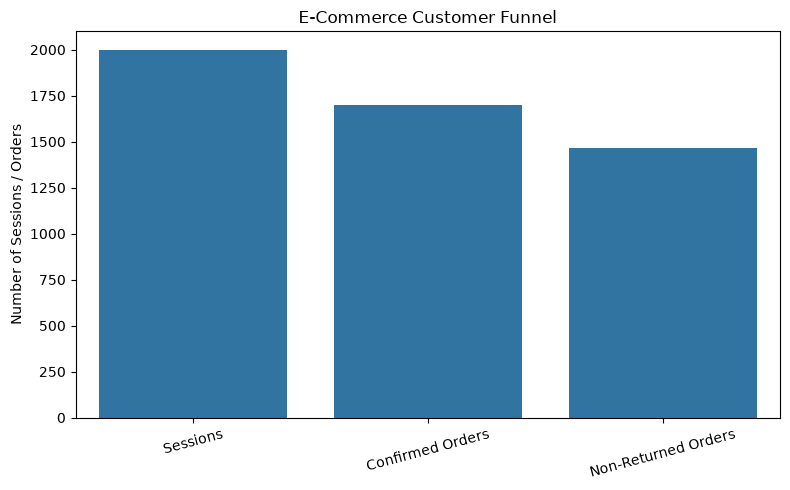

In [43]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=funnel,
    x='Stage',
    y='Count'
)

plt.title('E-Commerce Customer Funnel')
plt.xlabel('')
plt.ylabel('Number of Sessions / Orders')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [44]:
# Campaign summary

campaign_analysis = (
    df.groupby('CampaignSchema')
      .agg(
          Sessions=('CustomerID', 'size'),
          Orders=('OrderCount', 'sum'),
          Returns=('ReturnCount', 'sum')
      )
      .reset_index()
)

# Revenue and profit from confirmed orders only
campaign_financials = (
    orders.groupby('CampaignSchema')
    .agg(
        Revenue=('Revenue', 'sum'),
        Profit=('Profit', 'sum')
    )
    .reset_index()
)

campaign_analysis = campaign_analysis.merge(
    campaign_financials,
    on='CampaignSchema',
    how='left'
)

campaign_analysis['ConversionRate'] = (
    campaign_analysis['Orders'] /
    campaign_analysis['Sessions'] * 100
)

campaign_analysis['ReturnRate'] = (
    campaign_analysis['Returns'] /
    campaign_analysis['Orders'] * 100
)

campaign_analysis['AOV'] = (
    campaign_analysis['Revenue'] /
    campaign_analysis['Orders']
)

campaign_analysis = campaign_analysis[
    [
        'CampaignSchema',
        'Sessions',
        'Orders',
        'Revenue',
        'Profit',
        'Returns',
        'ConversionRate',
        'ReturnRate',
        'AOV'
    ]
]

campaign_analysis.sort_values(
    'ConversionRate',
    ascending=False
)

,CampaignSchema,Sessions,Orders,Revenue,Profit,Returns,ConversionRate,ReturnRate,AOV
0,Billboard-QR code,317,278,205439,72918,42,87.697161,15.107914,738.989209
5,Twitter-ads,308,265,204102,72619,33,86.038961,12.452830,770.196226
3,Google-ads,345,296,233863,84224,48,85.797101,16.216216,790.077703
2,Facebook-ads,338,288,186171,66935,41,85.207101,14.236111,646.427083
4,Instagram-ads,361,300,279568,97838,35,83.102493,11.666667,931.893333
1,E-mails,331,273,174480,63378,37,82.477341,13.553114,639.120879


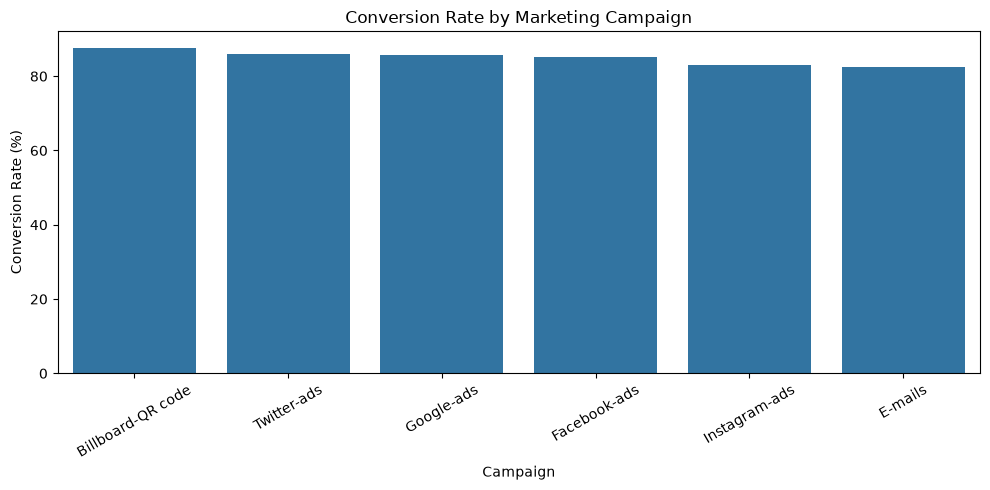

In [45]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=campaign_analysis.sort_values(
        'ConversionRate',
        ascending=False
    ),
    x='CampaignSchema',
    y='ConversionRate'
)

plt.title('Conversion Rate by Marketing Campaign')
plt.xlabel('Campaign')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

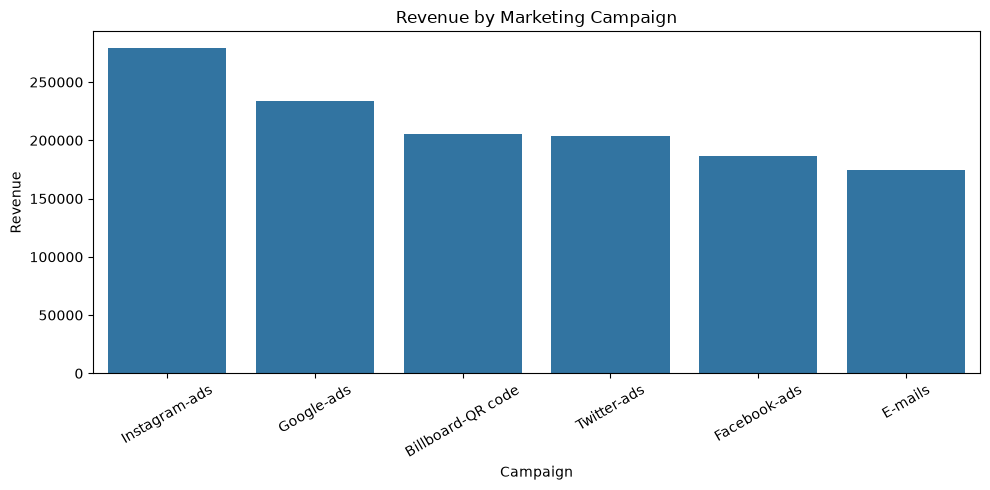

In [46]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=campaign_analysis.sort_values(
        'Revenue',
        ascending=False
    ),
    x='CampaignSchema',
    y='Revenue'
)

plt.title('Revenue by Marketing Campaign')
plt.xlabel('Campaign')
plt.ylabel('Revenue')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

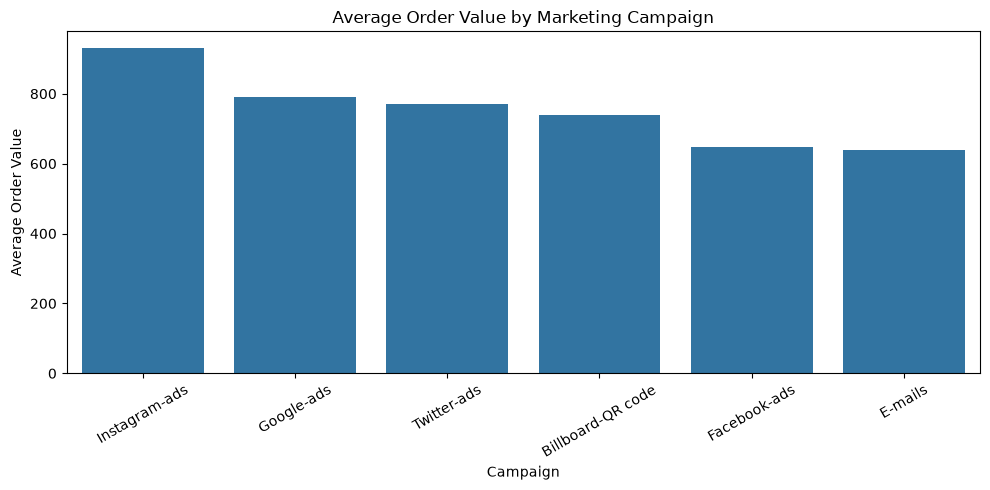

In [47]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=campaign_analysis.sort_values(
        'AOV',
        ascending=False
    ),
    x='CampaignSchema',
    y='AOV'
)

plt.title('Average Order Value by Marketing Campaign')
plt.xlabel('Campaign')
plt.ylabel('Average Order Value')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [48]:
# Category Analysis

category_analysis = (
    df.groupby('Category')
      .agg(
          Sessions=('CustomerID', 'size'),
          Orders=('OrderCount', 'sum'),
          Revenue=('Revenue', 'sum'),
          Profit=('Profit', 'sum'),
          Returns=('ReturnCount', 'sum')
      )
      .reset_index()
)

category_analysis['ConversionRate'] = (
    category_analysis['Orders'] /
    category_analysis['Sessions'] * 100
)

category_analysis['ReturnRate'] = (
    category_analysis['Returns'] /
    category_analysis['Orders'] * 100
)

category_analysis['AOV'] = (
    category_analysis['Revenue'] /
    category_analysis['Orders']
)

category_analysis.sort_values(
    'Revenue',
    ascending=False
)

,Category,Sessions,Orders,Revenue,Profit,Returns,ConversionRate,ReturnRate,AOV
1,electronics,361,304,932140,312195,36,84.210526,11.842105,3066.250000
3,home appliances,423,357,416110,159270,49,84.397163,13.725490,1165.574230
2,fashion,398,334,101760,40820,51,83.919598,15.269461,304.670659
0,books,406,345,38421,15911,50,84.975369,14.492754,111.365217
4,toys,412,360,34080,14433,50,87.378641,13.888889,94.666667


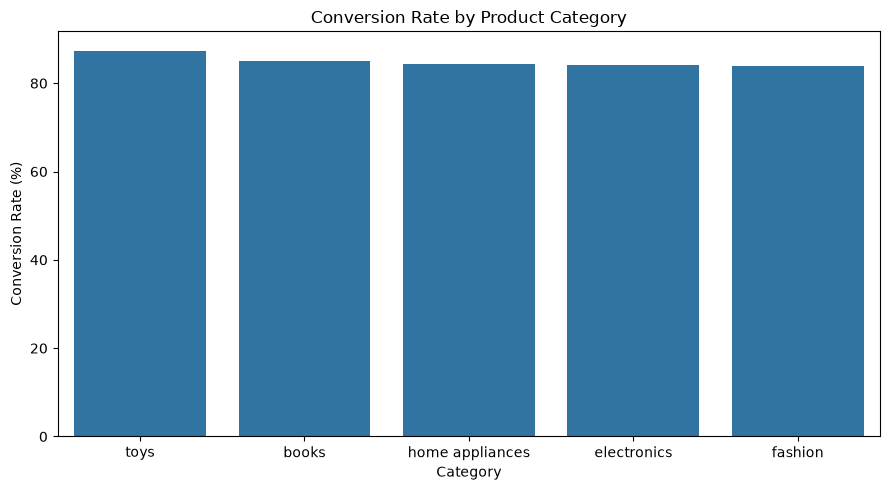

In [49]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=category_analysis.sort_values(
        'ConversionRate',
        ascending=False
    ),
    x='Category',
    y='ConversionRate'
)

plt.title('Conversion Rate by Product Category')
plt.xlabel('Category')
plt.ylabel('Conversion Rate (%)')

plt.tight_layout()
plt.show()

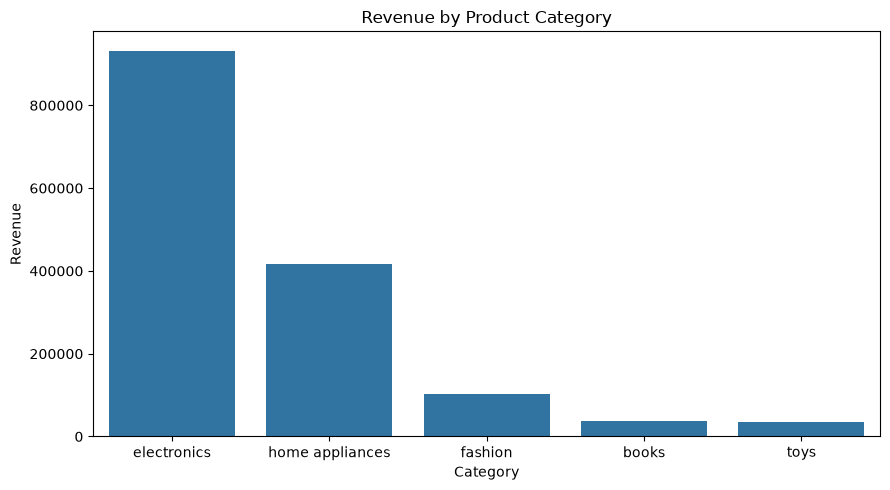

In [50]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=category_analysis.sort_values(
        'Revenue',
        ascending=False
    ),
    x='Category',
    y='Revenue'
)

plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Revenue')

plt.tight_layout()
plt.show()

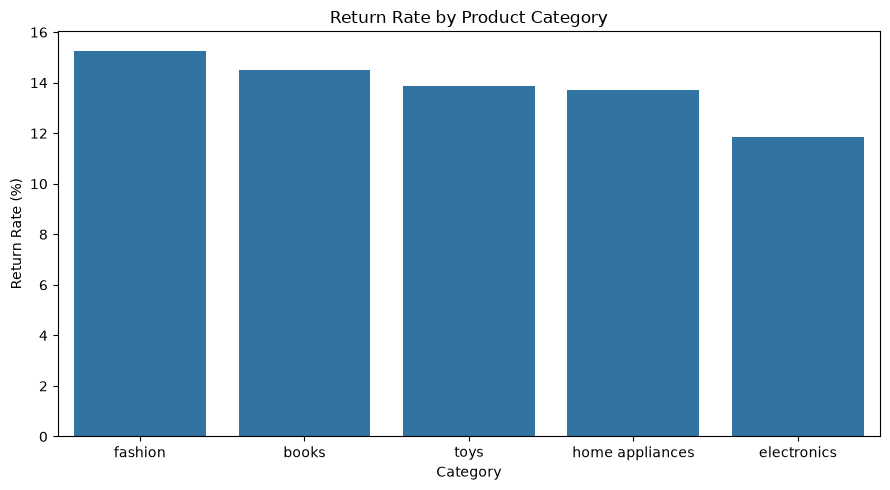

In [51]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=category_analysis.sort_values(
        'ReturnRate',
        ascending=False
    ),
    x='Category',
    y='ReturnRate'
)

plt.title('Return Rate by Product Category')
plt.xlabel('Category')
plt.ylabel('Return Rate (%)')

plt.tight_layout()
plt.show()

In [52]:
# Returns Analysis

return_analysis = (
    df[df['IsReturned']]
    .groupby('ReturnReason')
    .size()
    .reset_index(name='Returns')
    .sort_values(
        'Returns',
        ascending=False
    )
)

return_analysis

,ReturnReason,Returns
3,Poor Value,55
4,Wrong Item,49
1,Arrived Late,47
0,Arrived Damaged,45
2,Poor Quality,40


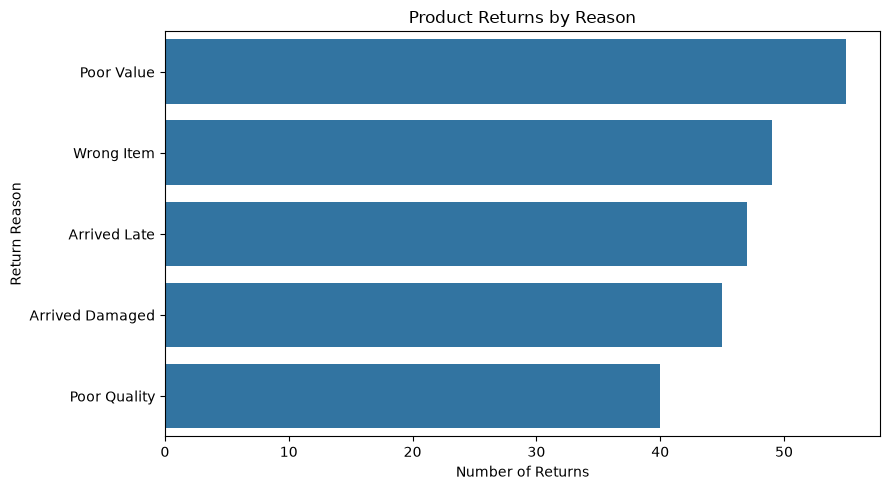

In [53]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=return_analysis,
    x='Returns',
    y='ReturnReason'
)

plt.title('Product Returns by Reason')
plt.xlabel('Number of Returns')
plt.ylabel('Return Reason')

plt.tight_layout()
plt.show()

In [54]:
# Customer Segment Analysis

age_analysis = (
    df.groupby('AgeGroup', observed=True)
      .agg(
          Sessions=('CustomerID', 'size'),
          Orders=('OrderCount', 'sum'),
          Revenue=('Revenue', 'sum'),
          Profit=('Profit', 'sum'),
          Returns=('ReturnCount', 'sum')
      )
      .reset_index()
)

age_analysis['ConversionRate'] = (
    age_analysis['Orders'] /
    age_analysis['Sessions'] * 100
)

age_analysis['ReturnRate'] = (
    age_analysis['Returns'] /
    age_analysis['Orders'] * 100
)

age_analysis['AOV'] = (
    age_analysis['Revenue'] /
    age_analysis['Orders']
)

age_analysis

,AgeGroup,Sessions,Orders,Revenue,Profit,Returns,ConversionRate,ReturnRate,AOV
0,18-25,356,298,296141,104535,36,83.707865,12.080537,993.761745
1,26-35,324,279,246246,86611,40,86.111111,14.336918,882.602151
2,36-45,391,329,290617,103974,41,84.143223,12.462006,883.334347
3,46-55,305,256,246282,88227,42,83.934426,16.406250,962.039062
4,56+,624,538,443225,159282,77,86.217949,14.312268,823.838290


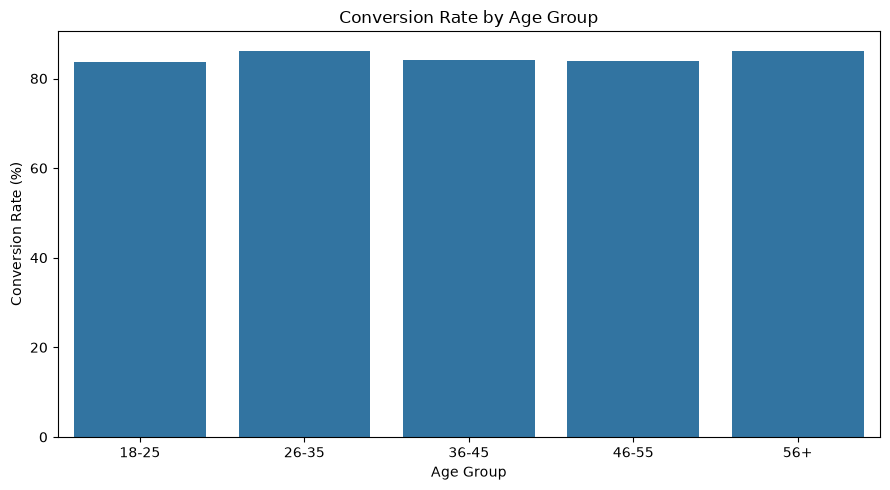

In [55]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=age_analysis,
    x='AgeGroup',
    y='ConversionRate'
)

plt.title('Conversion Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Conversion Rate (%)')

plt.tight_layout()
plt.show()

In [56]:
# Product Analysis

product_analysis = (
    orders.groupby('Product')
    .agg(
        Orders=('CustomerID', 'size'),
        Revenue=('Revenue', 'sum'),
        Profit=('Profit', 'sum'),
        Quantity=('Quantity', 'sum')
    )
    .reset_index()
)

product_analysis['AOV'] = (
    product_analysis['Revenue'] /
    product_analysis['Orders']
)

top_products = (
    product_analysis
    .sort_values('Revenue', ascending=False)
    .head(10)
)

top_products

,Product,Orders,Revenue,Profit,Quantity,AOV
17,television,84,432000,144000,288,5142.857143
7,laptop,68,325200,108400,271,4782.352941
9,microwave oven,102,192500,77000,385,1887.254902
4,electric stove,79,116800,43800,292,1478.481013
14,shoes,96,35300,14120,353,367.708333
10,mixer grinder,84,26460,8820,294,315.000000
6,jeans,89,22120,9480,316,248.539326
3,dress,77,21760,8160,272,282.597403
19,toaster,92,19320,6440,322,210.000000
18,textbook,86,14750,5900,295,171.511628


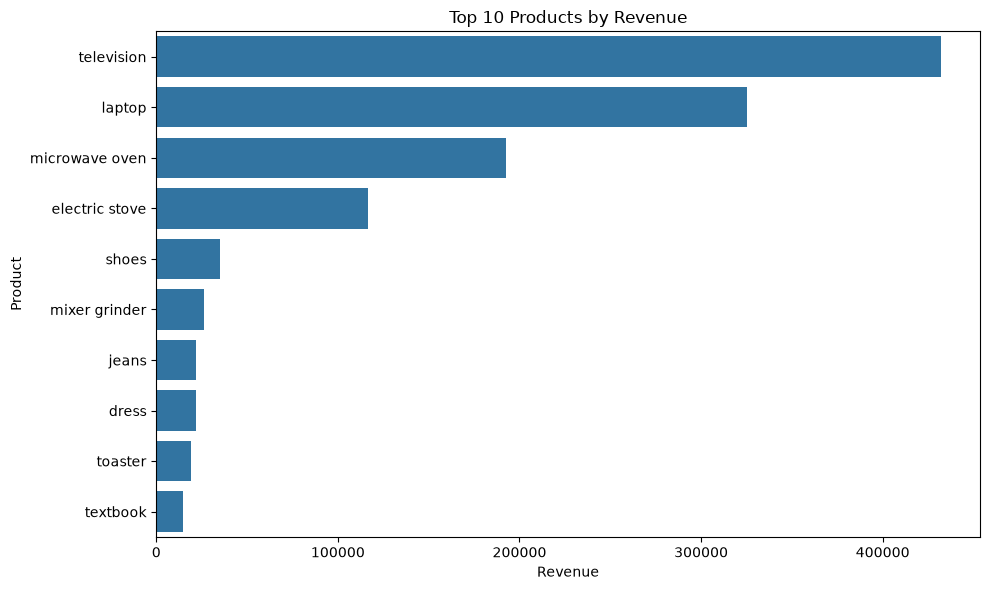

In [57]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_products,
    y='Product',
    x='Revenue'
)

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

In [58]:
# Session Analysis 

session_behavior = (
    df.groupby('IsConverted')['SessionDurationMinutes']
    .describe()
)

session_behavior

,count,mean,std,min,25%,50%,75%,max
IsConverted,,,,,,,,
False,300.0,20.826667,11.312967,3.0,11.0,20.0,31.0,40.0
True,1700.0,21.120000,7.581984,7.0,15.0,21.0,28.0,35.0


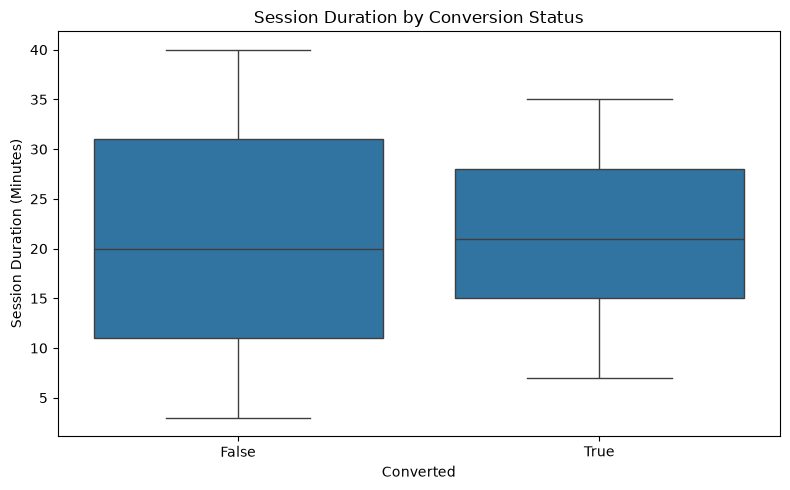

In [59]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='IsConverted',
    y='SessionDurationMinutes'
)

plt.title('Session Duration by Conversion Status')
plt.xlabel('Converted')
plt.ylabel('Session Duration (Minutes)')

plt.tight_layout()
plt.show()

In [60]:
# Time to Cart 

df.groupby('IsConverted')['TimeToCartMinutes'].describe()

,count,mean,std,min,25%,50%,75%,max
IsConverted,,,,,,,,
False,300.0,17.126667,7.095900,5.0,11.0,17.0,23.0,30.0
True,1700.0,17.620000,7.467036,5.0,11.0,17.5,24.0,30.0


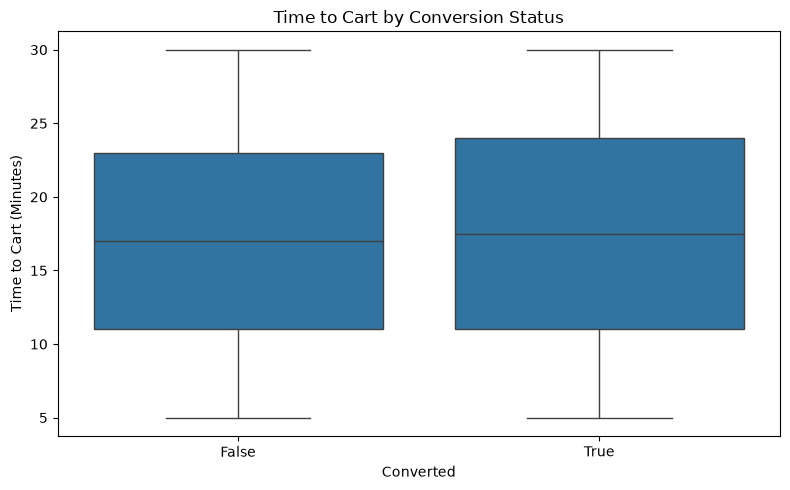

In [61]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='IsConverted',
    y='TimeToCartMinutes'
)

plt.title('Time to Cart by Conversion Status')
plt.xlabel('Converted')
plt.ylabel('Time to Cart (Minutes)')

plt.tight_layout()
plt.show()

In [70]:
df.to_csv(
    'Customer360Insights_cleaned.csv',
    index=False
)

In [62]:
df_mysql = df.copy()

In [63]:
df_mysql['OrderConfirmation'] = (
    df_mysql['OrderConfirmation']
    .astype(int)
)

df_mysql['IsConverted'] = (
    df_mysql['IsConverted']
    .astype(int)
)

df_mysql['IsReturned'] = (
    df_mysql['IsReturned']
    .astype(int)
)

df_mysql['OrderCount'] = (
    df_mysql['OrderCount']
    .astype(int)
)

df_mysql['ReturnCount'] = (
    df_mysql['ReturnCount']
    .astype(int)
)

In [64]:
df_mysql['OrderReturn'] = df_mysql['OrderReturn'].map({
    True: 1,
    False: 0
})

In [69]:
df_mysql.to_csv(
    'Customer360Insights_mysql.csv',
    index=False
)